In [1]:
library(anndataR)
library(SingleCellExperiment)
library(MAST)
library(parallelly)

options(mc.cores = availableCores())

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [3]:
sce <- read_h5ad("../data/combicells.h5ad", as= "SingleCellExperiment")

In [4]:
assays(sce)

List of length 4
names(4): log norm norm_scaled_genes sum

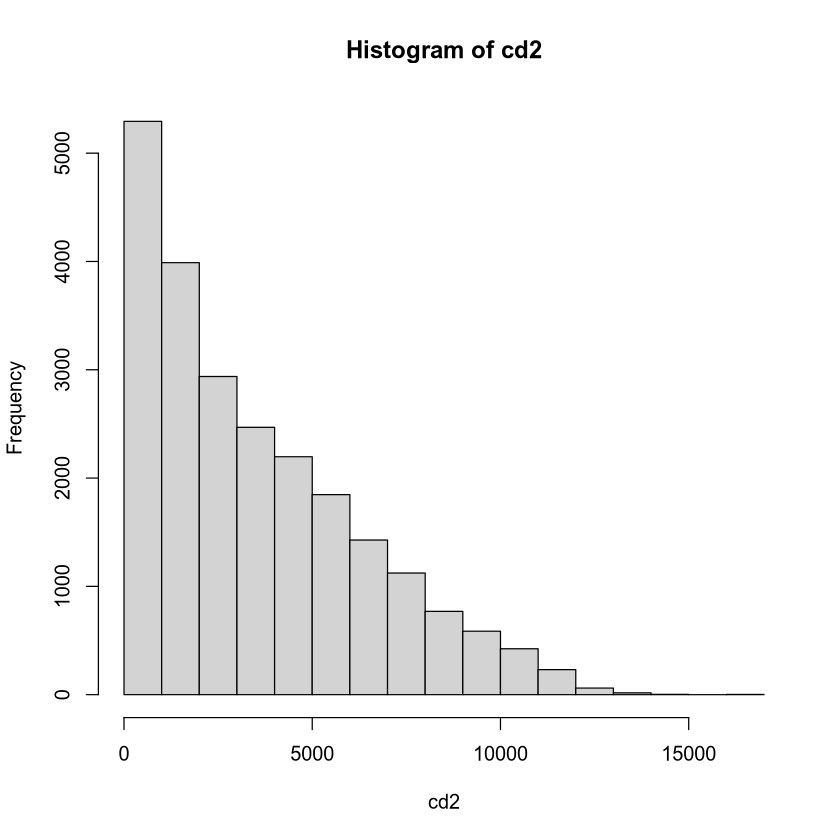

In [5]:
cd2 <- colSums(assay(sce, i= 4) > 0)
hist(cd2)

In [6]:
colData(sce)$detected <- scale(cd2)

In [7]:
sca <- SceToSingleCellAssay(sce)

`fData` has no primerid.  I'll make something up.



`cData` has no wellKey.  I'll make something up.

Assuming data assay in position 1, with name log is log-transformed.



In [8]:
sca

class: SingleCellAssay 
dim: 21318 23378 
metadata(0):
assays(4): log norm norm_scaled_genes sum
rownames(21318): ENSG00000233750 ENSG00000286448 ... ENSG00000271254
  ENSG00000276430
rowData names(11): gene_ids gene_symbol ... variances_norm primerid
colnames(23378): 0_Fibrous Ewing_Recurrence_Ewing sarcoma_Chest wall
  0_Recurrence Ewing_Initial diagnosis_Ewing sarcoma_Femur ...
  1660_Recurrence Ewing_Recurrence_Ewing sarcoma_Lung 1661_Recurrence
  Ewing_Recurrence_Ewing sarcoma_Lung
colData names(7): agg_groups idents ... detected wellKey
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [ ]:
zlmId <- zlm(~ idents + diagnosis + disease_timing + detected, sca, exprs_values = "log")

Warning message in .nextMethod(object = object, value = value):
“Coefficients diagnosisEwing sarcoma, diagnosisRhabdomyosarcoma, disease_timingRecurrence are never estimible and will be dropped.”


In [ ]:
saveRDS(zlmId, file= "../data/mast_out.rds")